In [15]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://hdr.undp.org/sites/default/files/2025_HDR/HDR25_Composite_indices_complete_time_series.csv"
df = pd.read_csv(url, encoding="latin-1", storage_options={"User-Agent": "Mozilla/5.0"})

print(df.shape)
print(df.columns.tolist()[:12])
df.head()

(206, 1112)
['iso3', 'country', 'hdicode', 'region', 'hdi_rank_2023', 'hdi_1990', 'hdi_1991', 'hdi_1992', 'hdi_1993', 'hdi_1994', 'hdi_1995', 'hdi_1996']


,iso3,country,hdicode,region,hdi_rank_2023,hdi_1990,hdi_1991,hdi_1992,hdi_1993,hdi_1994,...,pop_total_2014,pop_total_2015,pop_total_2016,pop_total_2017,pop_total_2018,pop_total_2019,pop_total_2020,pop_total_2021,pop_total_2022,pop_total_2023
0,AFG,Afghanistan,Low,SA,181.0,0.285,0.291,0.301,0.311,0.305,...,32.792523,33.831764,34.700612,35.688935,36.743039,37.856121,39.068979,40.000412,40.578842,41.454761
1,ALB,Albania,Very High,ECA,71.0,0.654,0.638,0.622,0.624,0.629,...,2.903749,2.898632,2.897867,2.898242,2.894231,2.885009,2.871954,2.849636,2.827608,2.811655
2,DZA,Algeria,High,AS,96.0,0.595,0.596,0.601,0.603,0.603,...,39.205030,40.019529,40.850721,41.689299,42.505035,43.294546,44.042091,44.761099,45.477390,46.164219
3,AND,Andorra,Very High,NaN,32.0,NaN,NaN,NaN,NaN,NaN,...,0.073737,0.072174,0.072181,0.073762,0.075162,0.076473,0.077380,0.078364,0.079705,0.080856
4,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,27.160770,28.157798,29.183070,30.234839,31.297155,32.375633,33.451132,34.532429,35.635029,36.749906


In [16]:
codes = ["CPV", "GHA", "SEN", "CIV", "NGA", "TGO", "BEN", "MLI", "NER", "SLE", "RWA"]

sel = df[df["iso3"].isin(codes)]
print(len(sel), "pays trouvés sur 11")
print(sel["country"].tolist())

11 pays trouvés sur 11
['Benin', 'Cabo Verde', "Côte d'Ivoire", 'Ghana', 'Mali', 'Niger', 'Nigeria', 'Rwanda', 'Senegal', 'Sierra Leone', 'Togo']


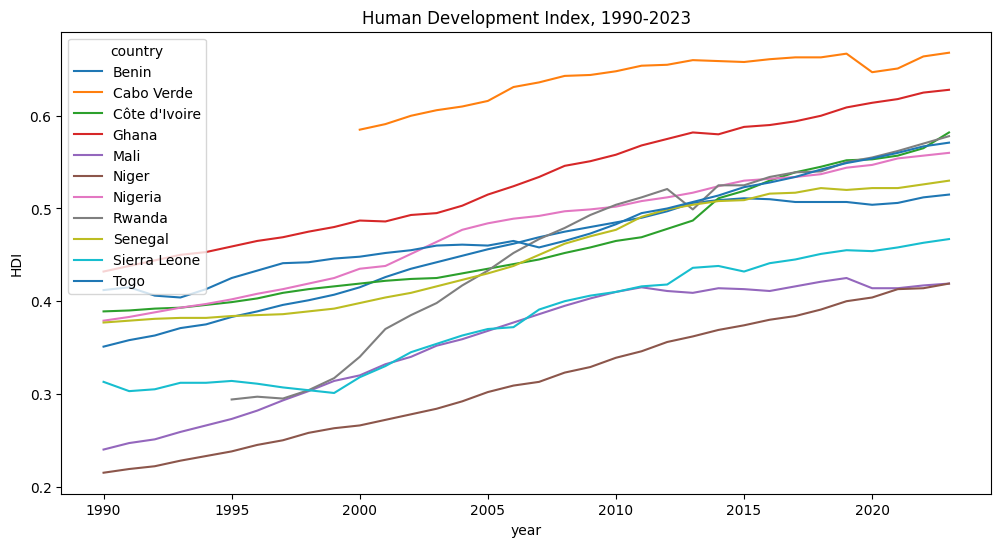

In [17]:
hdi_cols = [c for c in df.columns if c.startswith("hdi_") and c[4:].isdigit()]

hdi = sel.melt(id_vars="country", value_vars=hdi_cols,
               var_name="year", value_name="hdi")
hdi["year"] = hdi["year"].str.replace("hdi_", "").astype(int)

pivot = hdi.pivot(index="year", columns="country", values="hdi")
pivot.plot(figsize=(12, 6), title="Human Development Index, 1990-2023")
plt.ylabel("HDI")
plt.show()

In [18]:
last = pivot.index.max()

growth = pd.DataFrame({
    "HDI_1990": pivot.loc[1990],
    f"HDI_{last}": pivot.loc[last],
})
growth["gain"] = (growth[f"HDI_{last}"] - growth["HDI_1990"]).round(3)
growth["gain_%"] = (growth["gain"] / growth["HDI_1990"] * 100).round(1)
growth = growth.sort_values("gain", ascending=False)

print("Valeurs manquantes par pays :")
print(pivot.isna().sum())
growth

Valeurs manquantes par pays :
country
Benin             0
Cabo Verde       10
Côte d'Ivoire     0
Ghana             0
Mali              0
Niger             0
Nigeria           0
Rwanda            5
Senegal           0
Sierra Leone      0
Togo              0
dtype: int64


,HDI_1990,HDI_2023,gain,gain_%
country,,,,
Niger,0.215,0.419,0.204,94.9
Ghana,0.432,0.628,0.196,45.4
Côte d'Ivoire,0.389,0.582,0.193,49.6
Nigeria,0.379,0.560,0.181,47.8
Mali,0.240,0.419,0.179,74.6
Benin,0.351,0.515,0.164,46.7
Togo,0.412,0.571,0.159,38.6
Sierra Leone,0.313,0.467,0.154,49.2
Senegal,0.377,0.530,0.153,40.6


In [19]:
first_year = pivot.apply(lambda s: s.first_valid_index())
last_year = pivot.apply(lambda s: s.last_valid_index())

growth = pd.DataFrame({
    "first_year": first_year,
    "last_year": last_year,
    "HDI_first": [pivot.loc[first_year[c], c] for c in pivot.columns],
    "HDI_last": [pivot.loc[last_year[c], c] for c in pivot.columns],
})
growth["gain"] = (growth["HDI_last"] - growth["HDI_first"]).round(3)
growth = growth.sort_values("gain", ascending=False)

print(growth.to_string())
print()
print(pivot.isna().sum())

               first_year  last_year  HDI_first  HDI_last   gain
country                                                         
Rwanda               1995       2023      0.294     0.578  0.284
Niger                1990       2023      0.215     0.419  0.204
Ghana                1990       2023      0.432     0.628  0.196
Côte d'Ivoire        1990       2023      0.389     0.582  0.193
Nigeria              1990       2023      0.379     0.560  0.181
Mali                 1990       2023      0.240     0.419  0.179
Benin                1990       2023      0.351     0.515  0.164
Togo                 1990       2023      0.412     0.571  0.159
Sierra Leone         1990       2023      0.313     0.467  0.154
Senegal              1990       2023      0.377     0.530  0.153
Cabo Verde           2000       2023      0.585     0.668  0.083

country
Benin             0
Cabo Verde       10
Côte d'Ivoire     0
Ghana             0
Mali              0
Niger             0
Nigeria           0
Rwanda

In [20]:
cols = {"le_": "Life expectancy", "mys_": "Mean years of schooling", "gnipc_": "GNI per capita (PPP$)"}
comp = sel.set_index("country")[[f"{k}{last}" for k in cols]]
comp.columns = list(cols.values())
comp["HDI"] = pivot.loc[last]
comp = comp.sort_values("HDI", ascending=False)
comp

,Life expectancy,Mean years of schooling,GNI per capita (PPP$),HDI
country,,,,
Cabo Verde,76.059,6.090039,8165.379172,0.668
Ghana,65.498,7.107210,6846.352204,0.628
Côte d'Ivoire,61.944,4.870000,6735.416265,0.582
Rwanda,67.785,4.880000,2970.559461,0.578
Togo,62.739,5.861115,2855.963828,0.571
Nigeria,54.462,7.585970,5569.374975,0.560
Senegal,68.683,2.934554,4202.030729,0.530
Benin,60.774,3.194200,3805.527516,0.515
Sierra Leone,61.786,3.535298,1713.727772,0.467


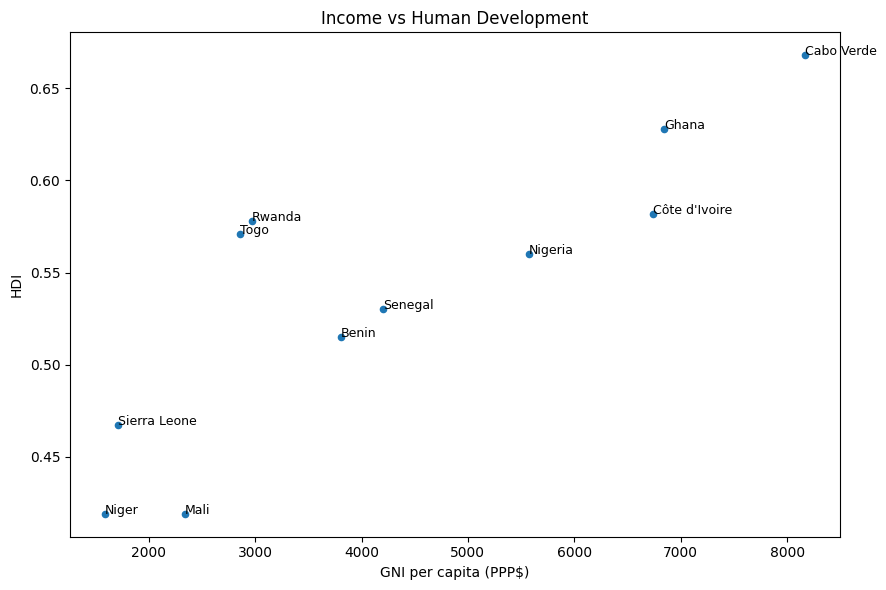

In [21]:
comp.plot(kind="scatter", x="GNI per capita (PPP$)", y="HDI", figsize=(9, 6),
          title="Income vs Human Development")
for name, row in comp.iterrows():
    plt.annotate(name, (row["GNI per capita (PPP$)"], row["HDI"]), fontsize=9)
plt.tight_layout()
plt.savefig("income_vs_hdi.png", dpi=150)
plt.show()


In [22]:
p2000 = pivot.loc[2000:]
common = pd.DataFrame({"HDI_2000": p2000.loc[2000], "HDI_2023": p2000.loc[2023]})
common["gain"] = (common["HDI_2023"] - common["HDI_2000"]).round(3)
common = common.sort_values("gain", ascending=False)
print(common.to_string())

print()

comp = sel.set_index("country")[["le_2023", "mys_2023", "gnipc_2023"]]
comp["HDI_2023"] = pivot.loc[2023]
print(comp.sort_values("HDI_2023", ascending=False).round(3).to_string())

               HDI_2000  HDI_2023   gain
country                                 
Rwanda            0.340     0.578  0.238
Côte d'Ivoire     0.419     0.582  0.163
Niger             0.266     0.419  0.153
Sierra Leone      0.318     0.467  0.149
Ghana             0.487     0.628  0.141
Senegal           0.398     0.530  0.132
Nigeria           0.435     0.560  0.125
Togo              0.448     0.571  0.123
Benin             0.415     0.515  0.100
Mali              0.320     0.419  0.099
Cabo Verde        0.585     0.668  0.083

               le_2023  mys_2023  gnipc_2023  HDI_2023
country                                               
Cabo Verde      76.059     6.090    8165.379     0.668
Ghana           65.498     7.107    6846.352     0.628
Côte d'Ivoire   61.944     4.870    6735.416     0.582
Rwanda          67.785     4.880    2970.559     0.578
Togo            62.739     5.861    2855.964     0.571
Nigeria         54.462     7.586    5569.375     0.560
Senegal         68.683    

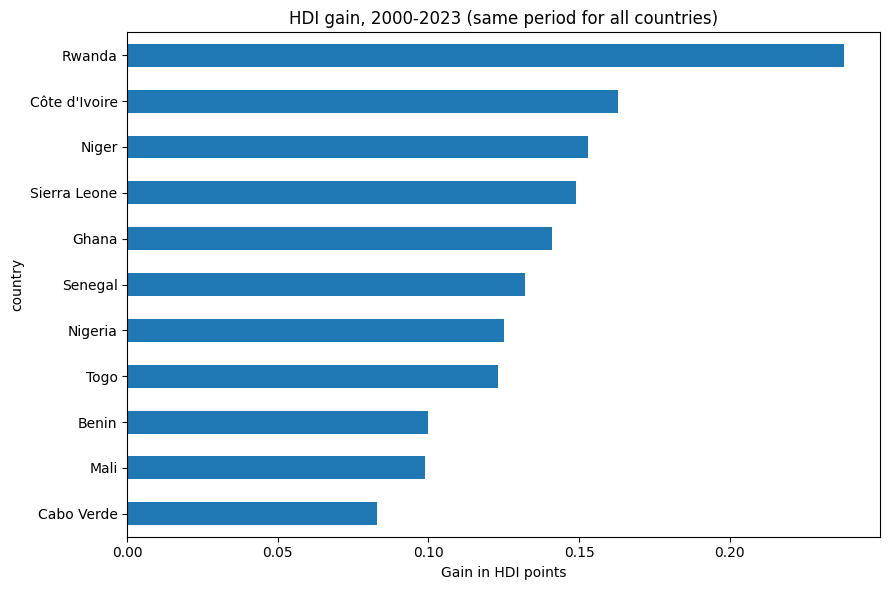

In [23]:
common["gain"].plot(kind="barh", figsize=(9, 6),
                    title="HDI gain, 2000-2023 (same period for all countries)")
plt.gca().invert_yaxis()
plt.xlabel("Gain in HDI points")
plt.tight_layout()
plt.savefig("hdi_gain_2000_2023.png", dpi=150)
plt.show()